In [1]:
# imports
import pandas as pd
import os

# download the test parqet file
df= pd.read_parquet("train_data.parquet")
display(df.head())

,Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,Dest,...,CRSDepDateTime,CRSDepDateTime_UTC,CRSArrDateTime,CRSArrDateTime_UTC,DepDateTime,DepDateTime_UTC,ArrDateTime,ArrDateTime_UTC,DayOfYear,knownWeatherDateTime_UTC
0,2013,1,1,2,2013-01-01,AA,N3ATAA,264,LAS,JFK,...,2013-01-01 08:20:00,2013-01-01 16:20:00+00:00,2013-01-01 16:20:00,2013-01-01 21:20:00+00:00,2013-01-01 08:19:00,2013-01-01 16:19:00+00:00,2013-01-01 16:04:00,2013-01-01 21:04:00+00:00,1,2013-01-01 14:00:00
1,2013,1,2,3,2013-01-02,AA,N3CAAA,264,LAS,JFK,...,2013-01-02 08:20:00,2013-01-02 16:20:00+00:00,2013-01-02 16:20:00,2013-01-02 21:20:00+00:00,2013-01-02 08:20:00,2013-01-02 16:20:00+00:00,2013-01-02 15:57:00,2013-01-02 20:57:00+00:00,2,2013-01-02 14:00:00
2,2013,1,3,4,2013-01-03,AA,N3HDAA,264,LAS,JFK,...,2013-01-03 08:20:00,2013-01-03 16:20:00+00:00,2013-01-03 16:20:00,2013-01-03 21:20:00+00:00,2013-01-03 09:15:00,2013-01-03 17:15:00+00:00,2013-01-03 17:04:00,2013-01-03 22:04:00+00:00,3,2013-01-03 14:00:00
3,2013,1,4,5,2013-01-04,AA,N3BYAA,264,LAS,JFK,...,2013-01-04 08:20:00,2013-01-04 16:20:00+00:00,2013-01-04 16:20:00,2013-01-04 21:20:00+00:00,2013-01-04 11:14:00,2013-01-04 19:14:00+00:00,2013-01-04 19:16:00,2013-01-05 00:16:00+00:00,4,2013-01-04 14:00:00
4,2013,1,5,6,2013-01-05,AA,N3JDAA,264,LAS,JFK,...,2013-01-05 08:20:00,2013-01-05 16:20:00+00:00,2013-01-05 16:20:00,2013-01-05 21:20:00+00:00,2013-01-05 08:15:00,2013-01-05 16:15:00+00:00,2013-01-05 16:02:00,2013-01-05 21:02:00+00:00,5,2013-01-05 14:00:00


In [12]:
# get all columns of the dataset
print(df.columns)

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline',
       'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay',
       'DepDelayMinutes', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn',
       'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'Cancelled',
       'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
       'SecurityDelay', 'LateAircraftDelay', 'FlightId', 'Timezone_Origin',
       'TZ_Origin', 'Timezone_Dest', 'TZ_Dest', 'CRSDepDateTime',
       'CRSDepDateTime_UTC', 'CRSArrDateTime', 'CRSArrDateTime_UTC',
       'DepDateTime', 'DepDateTime_UTC', 'ArrDateTime', 'ArrDateTime_UTC',
       'DayOfYear', 'knownWeatherDateTime_UTC'],
      dtype='str')


In [13]:
# plot for each year the disribution of ArrDelay in minutes.
import matplotlib.pyplot as plt
import seaborn as sns
# take a copy of the datset with only the ArrDelay and Flight Date columns
df_delay = df[["ArrDelayMinutes", "FlightDate","Year","Month","DayOfYear"]].copy()

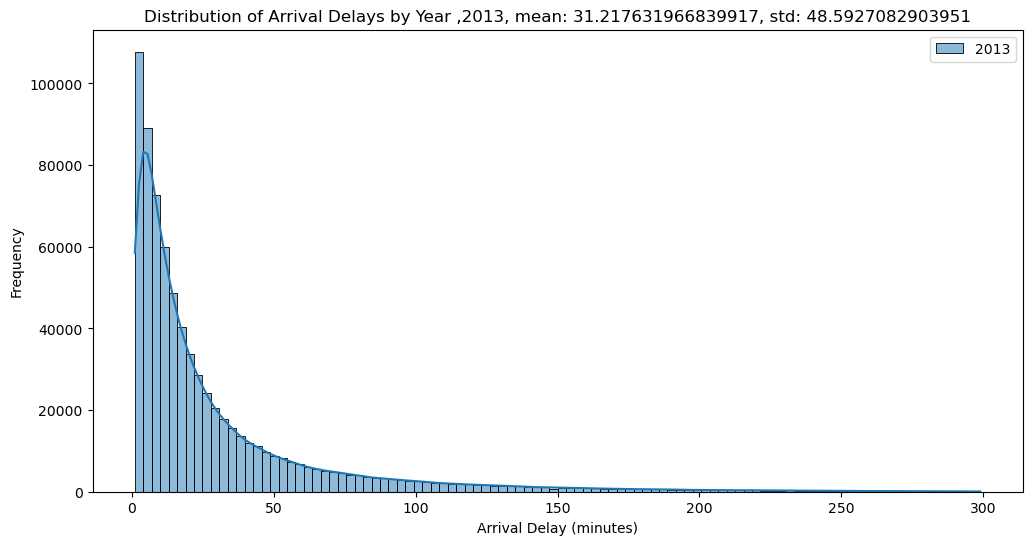

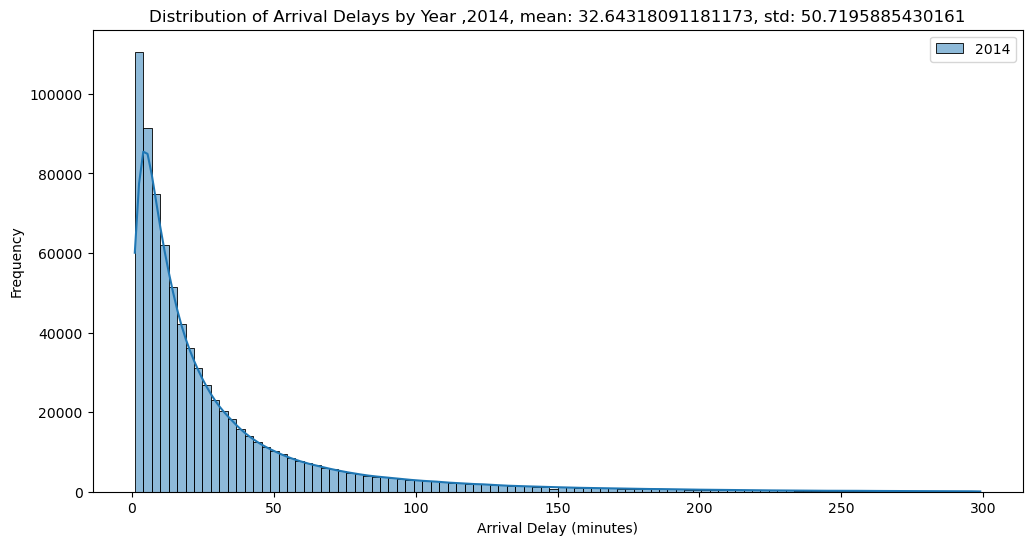

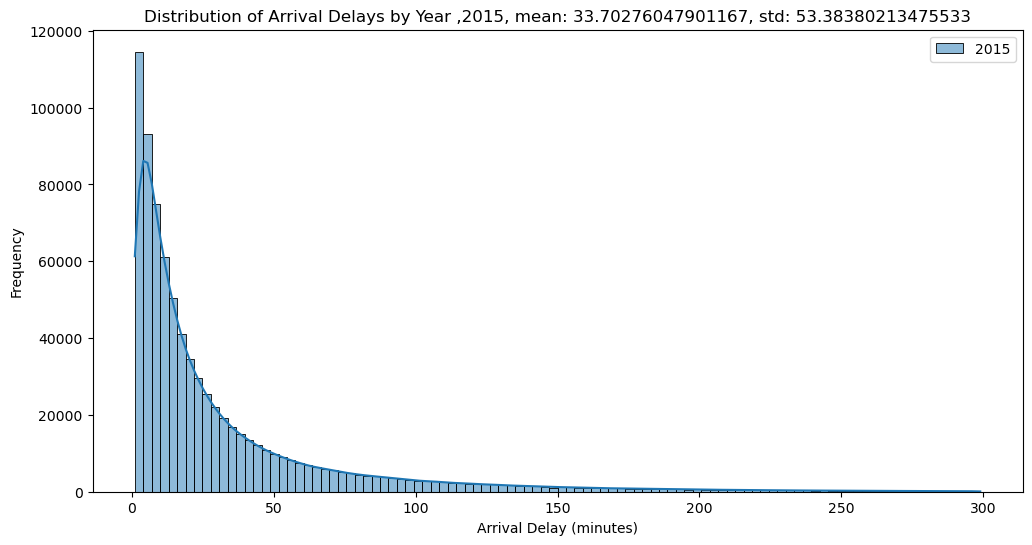

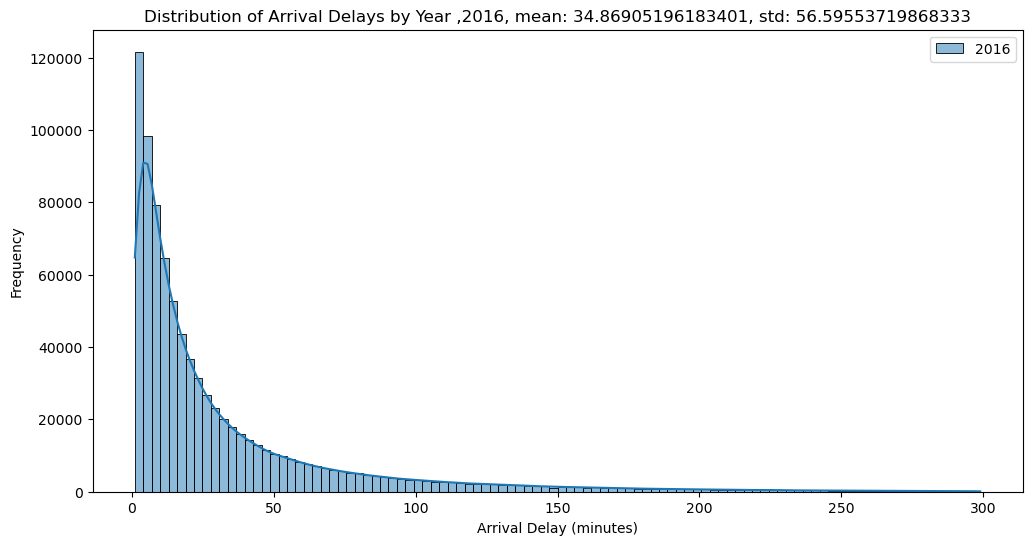

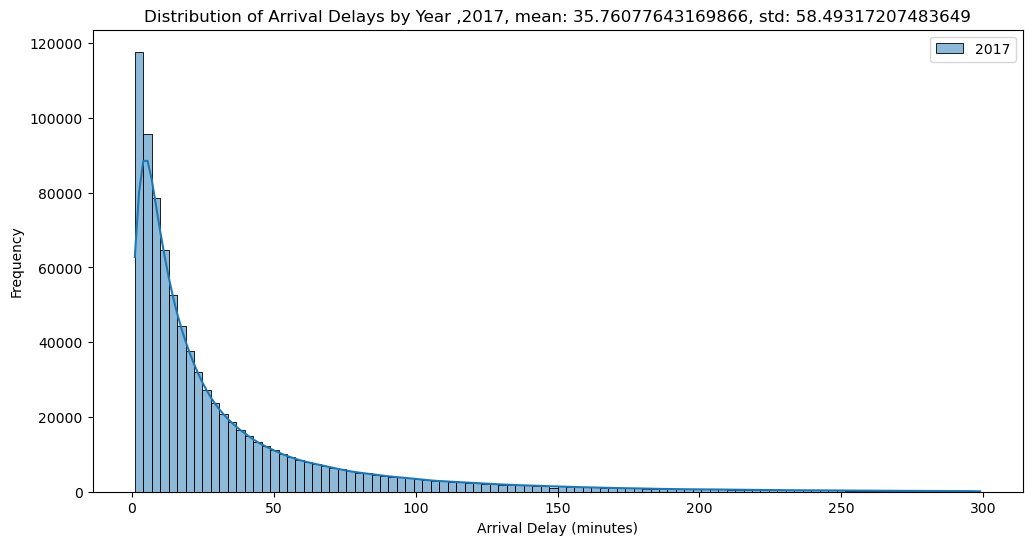

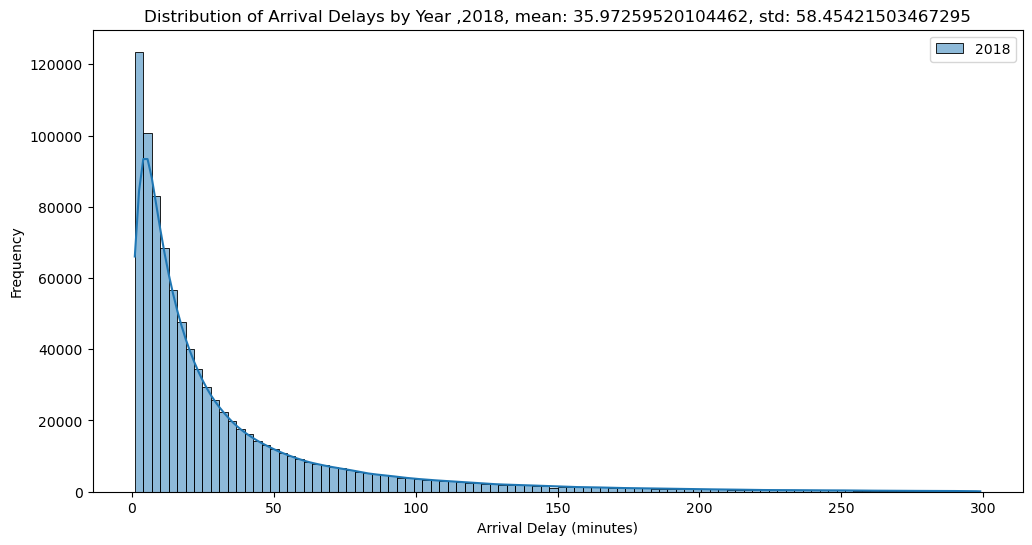

In [29]:
# plot the distribution of ArrDelay for each year
for year in df_delay["Year"].unique():
    plt.figure(figsize=(12, 6))
    data = df_delay[df_delay["Year"] == year]
    # drop all rows where the ArrDealyMinutes is 0
    data = data[data["ArrDelayMinutes"] != 0]

    # calculate basic statistics
    mean_delay = data["ArrDelayMinutes"].mean()
    std_delay = data["ArrDelayMinutes"].std()
    #desity plot for ArrDelay

    # remove outliers for better visualization
    data = data[(data["ArrDelayMinutes"] > -60) & (data["ArrDelayMinutes"] < 300)]
    sns.histplot(data["ArrDelayMinutes"], bins=100, kde=True, label=str(year))
    plt.xlabel("Arrival Delay (minutes)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Arrival Delays by Year ,{year}, mean: {mean_delay}, std: {std_delay}")
    plt.legend()
    plt.show()

In [10]:
# what is the percentage of flights that are delayed by more than 15 minutes for each year?
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    total_flights = len(data)
    delayed_flights = len(data[data["ArrDelayMinutes"] > 15])
    percentage_delayed = (delayed_flights / total_flights) * 100
    print(f"Year: {year}, Percentage of flights delayed by more than 15 minutes: {percentage_delayed:.2f}%")

Year: 2013, Percentage of flights delayed by more than 15 minutes: 19.68%
Year: 2014, Percentage of flights delayed by more than 15 minutes: 21.33%
Year: 2015, Percentage of flights delayed by more than 15 minutes: 18.03%
Year: 2016, Percentage of flights delayed by more than 15 minutes: 17.77%
Year: 2017, Percentage of flights delayed by more than 15 minutes: 18.38%
Year: 2018, Percentage of flights delayed by more than 15 minutes: 19.01%


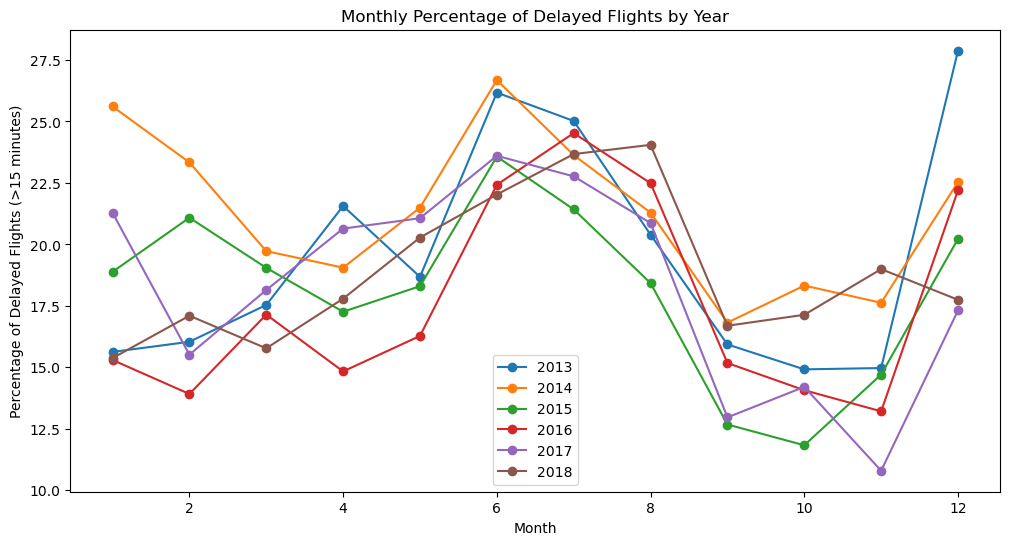

In [16]:
plt.figure(figsize=(12, 6))
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    monthly_delays = data.groupby("Month").apply(lambda x: (x["ArrDelayMinutes"] > 15).mean() * 100)
    plt.plot(monthly_delays.index, monthly_delays.values, marker="o", label=str(year))
plt.xlabel("Month")
plt.ylabel("Percentage of Delayed Flights (>15 minutes)")
plt.title("Monthly Percentage of Delayed Flights by Year")
plt.legend()
plt.show()

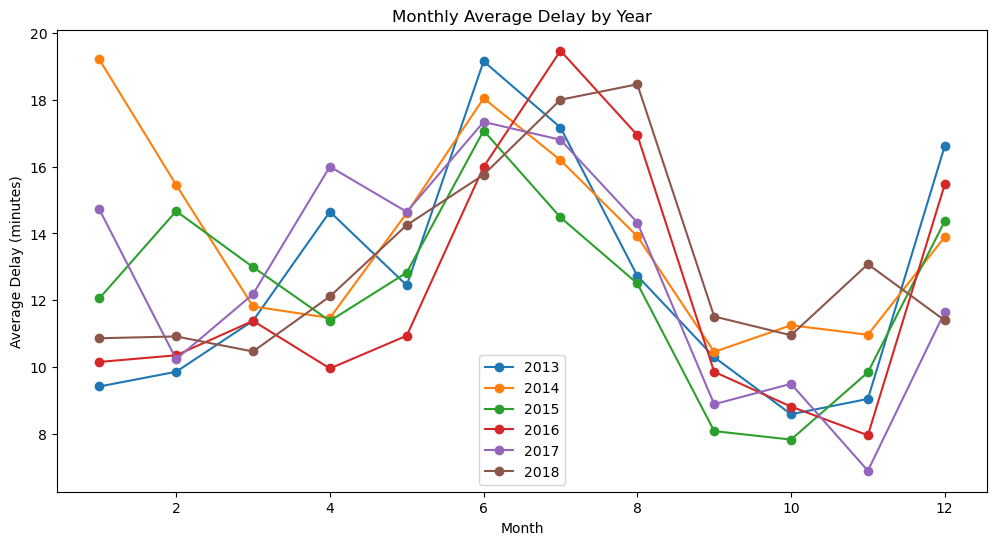

In [17]:
plt.figure(figsize=(12, 6))
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    # get the average delay for month of the year
    monthly_delays = data.groupby("Month").apply(lambda x: x["ArrDelayMinutes"].mean())
    plt.plot(monthly_delays.index, monthly_delays.values, marker="o", label=str(year))
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.title("Monthly Average Delay by Year")
plt.legend()
plt.show()

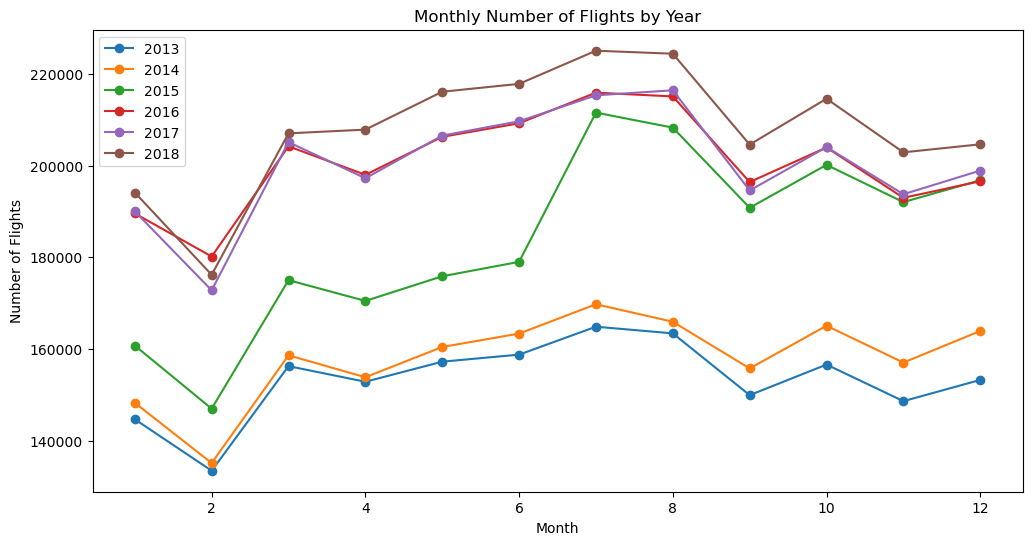

In [42]:
plt.figure(figsize=(12, 6))
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    # get the number of flights for month of the year
    number_of_flights = data.groupby("Month").size()
    plt.plot(number_of_flights.index, number_of_flights.values, marker="o", label=str(year))
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.title("Monthly Number of Flights by Year")
plt.legend()
plt.show()

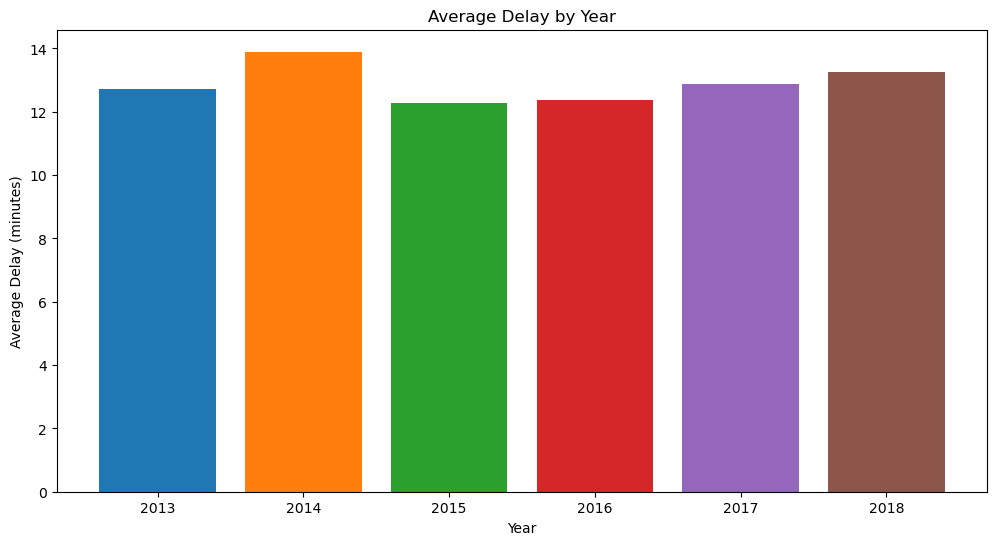

In [18]:
# plot the avergae dealy of the Year over the years
plt.figure(figsize=(12, 6))
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    average_delay = data["ArrDelayMinutes"].mean()
    plt.bar(str(year), average_delay)
plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.title("Average Delay by Year")
plt.show()


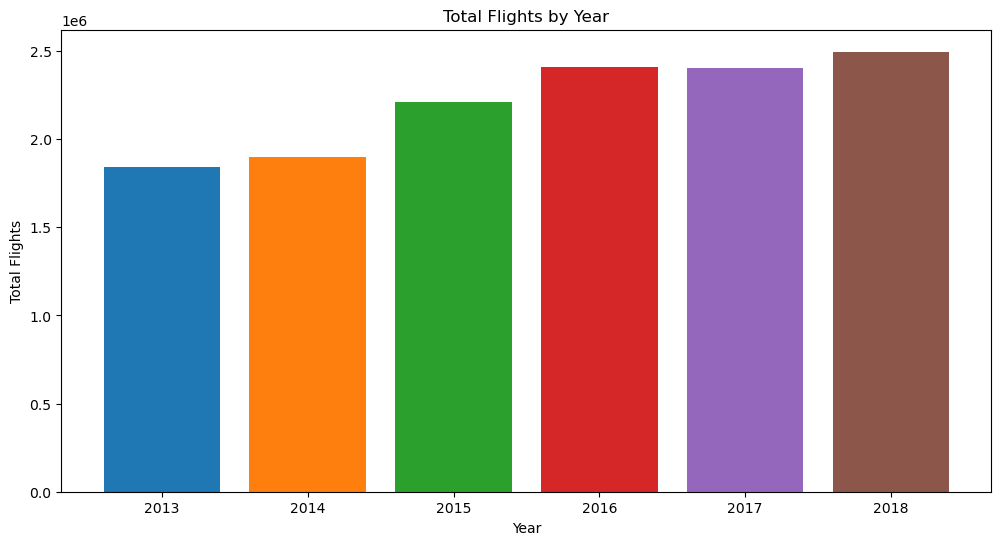

In [19]:
# plot the number of flight for each year
plt.figure(figsize=(12, 6))
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    total_flights = len(data)
    plt.bar(str(year), total_flights)
plt.xlabel("Year")
plt.ylabel("Total Flights")
plt.title("Total Flights by Year")
plt.show()

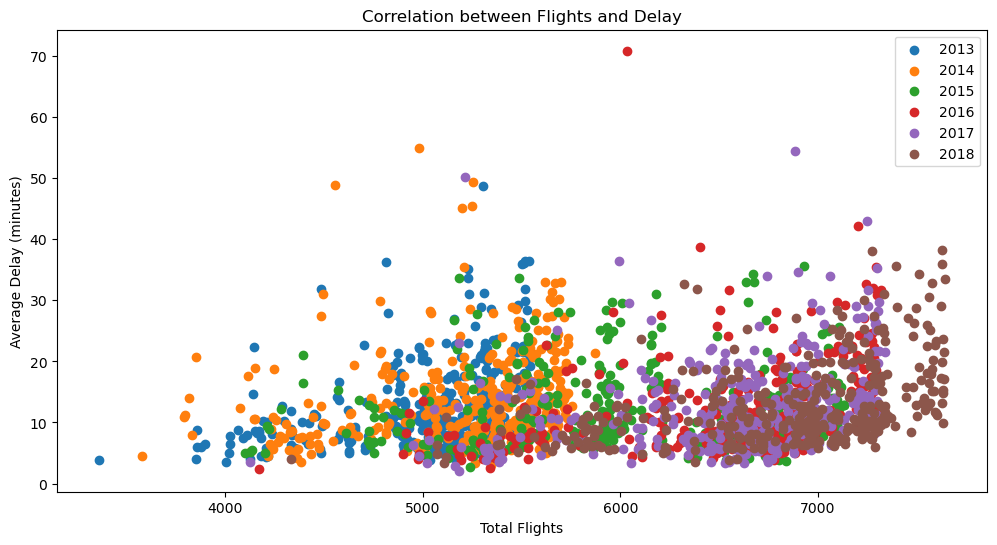

In [21]:
# plot correlation analysis of the number of flights Per Month and the avergae delay per month


plt.figure(figsize=(12, 6))
for year in df_delay["Year"].unique():
    data = df_delay[df_delay["Year"] == year]
    monthly_flights = data.groupby("FlightDate").size()
    monthly_average_delay = data.groupby("FlightDate")["ArrDelayMinutes"].mean()
    plt.scatter(monthly_flights, monthly_average_delay, label=str(year))
plt.xlabel("Total Flights")
plt.ylabel("Average Delay (minutes)")
plt.title("Correlation between Flights and Delay")
plt.legend()
plt.show()

In [22]:
# get a copy with the arrivaDealyMinute and the Distance columns
df_delay_distance = df[["ArrDelayMinutes", "Distance","DistanceGroup"]].copy()

Correlation between Arrival Delay and Distance: 0.00


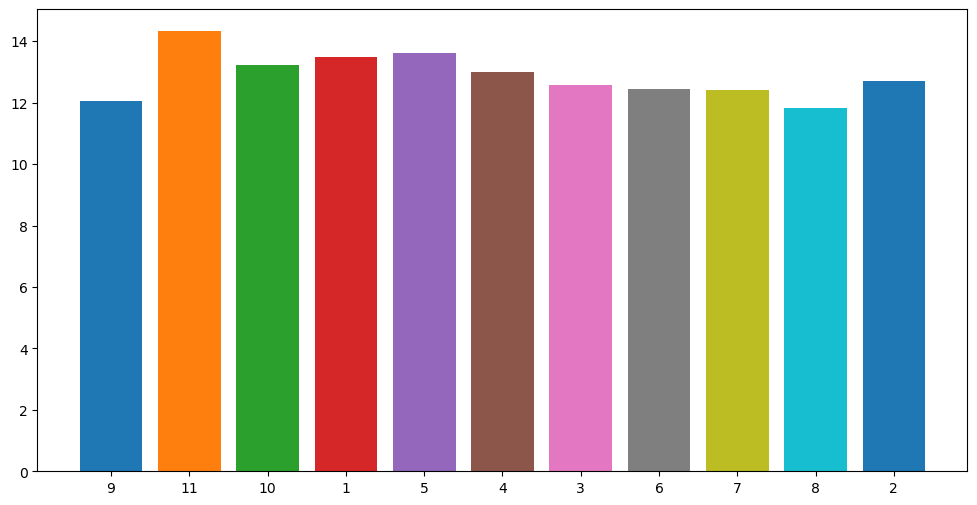

In [25]:
# plot the avergae Delay for each distance group
plt.figure(figsize=(12, 6))
for group in df_delay_distance["DistanceGroup"].unique():
    data = df_delay_distance[df_delay_distance["DistanceGroup"] == group]
    average_delay = data["ArrDelayMinutes"].mean()
    plt.bar(str(group), average_delay)

# what is the coorelation, between the distance and the delay?
correlation = df_delay_distance["ArrDelayMinutes"].corr(df_delay_distance["Distance"])
print(f"Correlation between Arrival Delay and Distance: {correlation:.2f}")

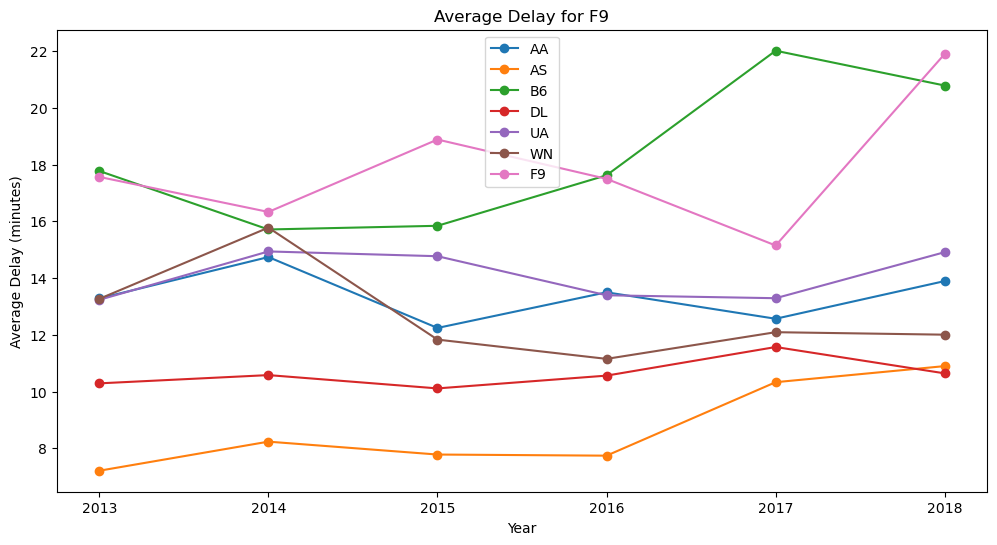

In [28]:
# get a copy of the dataset with the ArrDelayMinutes and date info and the airlines
df_delay_airline = df[["ArrDelayMinutes", "FlightDate","Year","Month","Reporting_Airline"]].copy()


# for every Airline plot the aver dealy of the Year over the years
plt.figure(figsize=(12, 6))
for airline in df_delay_airline["Reporting_Airline"].unique():
    data = df_delay_airline[df_delay_airline["Reporting_Airline"] == airline]
    average_delay = data.groupby("Year")["ArrDelayMinutes"].mean()
    plt.plot(average_delay.index, average_delay.values, marker="o", label=airline)
plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.title(f"Average Delay for {airline}")
plt.legend()
plt.show()

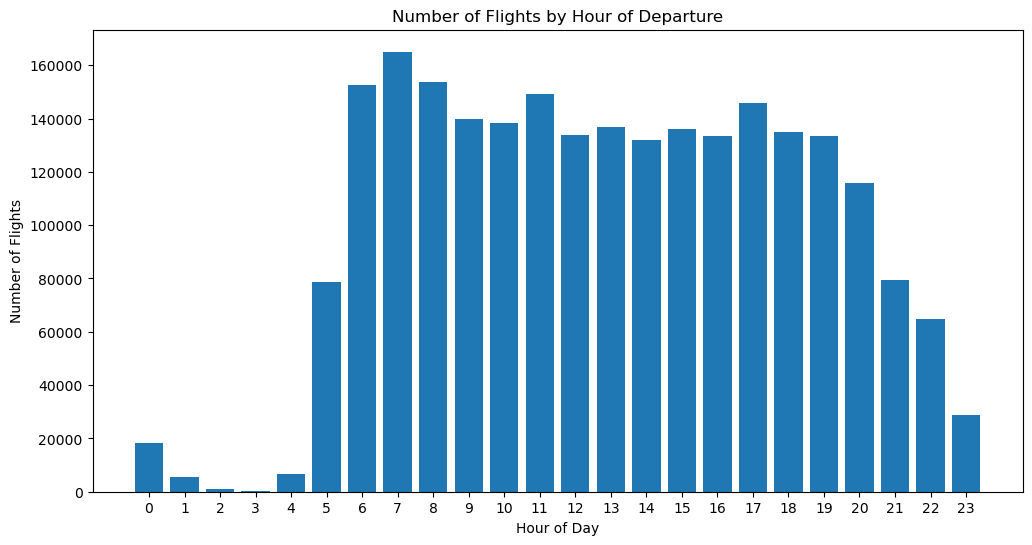

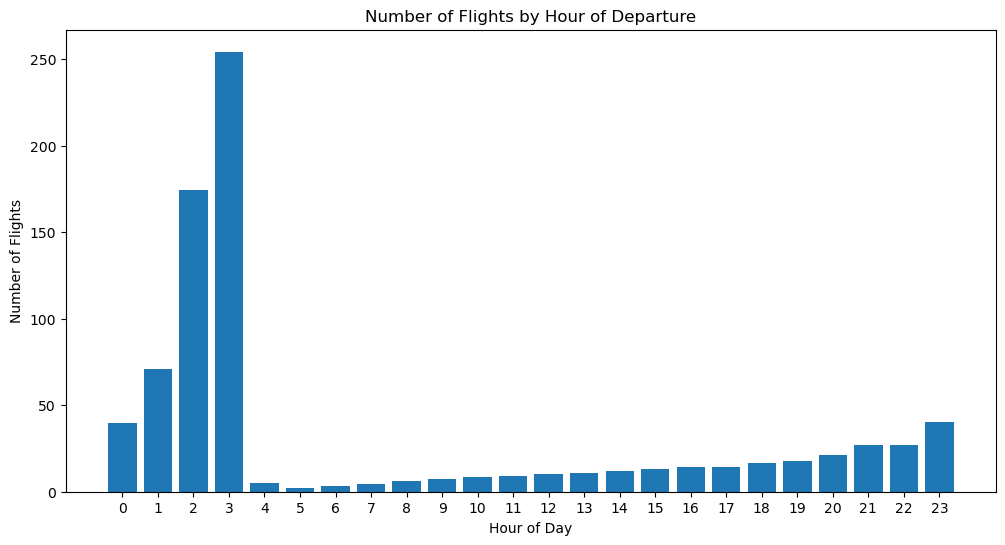

In [41]:
# take the standart dataaset, and plot the average delay, over the time of the day for the departure time
df_year = df[df["Year"] == 2016].copy()
# convert scheduled departure time to hour of day
df_year["DepHour"] = pd.to_datetime(
    df_year["DepTime"].astype(str),
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

# plot the average delay over the time of the day for the departure time
hourly_avg_delay = df_year.groupby("DepHour")["ArrDelayMinutes"].mean().reindex(range(24))
number_of_flights = df_year.groupby("DepHour").size().reindex(range(24))
plt.figure(figsize=(12, 6))
plt.bar(number_of_flights.index.astype(str), number_of_flights)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.title("Number of Flights by Hour of Departure")
plt.show()
plt.figure(figsize=(12, 6))
plt.bar(hourly_avg_delay.index.astype(str), hourly_avg_delay)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.title("Number of Flights by Hour of Departure")
plt.show()


In [ ]:
# plot 